# Data Science Lab Winter Project 2024/2025
## Age Detection
Within the field of speech processing, a long-standing task of interest is estimating the age of a speaker based on their vocal characteristics. Some systems are capable of analyzing spoken sentences to extract features that correlate with the speaker’s age. The process of estimating a speaker’s age from their speech is referred to as age estimation. The target (output) of the system is a single value representing the estimated age of the speaker.

Report by:
- Gosmar Dario: s337625
- Maretto Chiara: s339401

# 1 Imports
## 1.1 Library Import

In [36]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
import scipy
import os
import librosa

## 1.2 Dataset Import
The dataset is comprised of 3,624 samples: 2,933 samples for the **development set** and 691 samples for the **evaluation set**. Each sample corresponds to a spoken sentence, and the associated speaker’s age is provided as the target label. 
The speech samples have been collected in controlled conditions to ensure consistent feature extraction.

For each sample, a variety of acoustic and linguistic features have been extracted from the speech signal. These features form the dataset and include:
- **sampling rate**: the sampling rate of the audio signal, in Hz
- **age**: the chronological age of the speaker (target label)
- **gender**: the gender of the speake
- **ethnicity**: the ethnicity of the speaker
- **mean pitch**, **max pitch**, **min pitch**: mean, maximum, and minimum pitch of the speech signal, in Hz
- **jitter**: a measure of the variations in pitch, representing voice stability
- **shimmer**: a measure of amplitude variations in the speech signal
- **energy**: the overall energy of the speech signal
- **zcr mean**: the mean zero-crossing rate, indicating the number of times the signal changes sign
- **spectral centroid mean**: the mean spectral centroid, representing the “center of mass” of the frequency spectrum
- **tempo**: the estimated speaking rate, in beats per minute (BPM)
- **hnr**: the harmonic-to-noise ratio, indicating voice quality
- **num words**, **num characters**: the number of words and characters in the spoken sentence
- **num pauses**: the number of pauses detected in the speech
- **silence duration**: the total duration of silence within the speech signal, in seconds
- **path**: the file path to the audio recording

In [37]:
dev_df = pd.read_csv("DSL_Winter_Project_2025/development.csv")
eval_df = pd.read_csv("DSL_Winter_Project_2025/evaluation.csv")

# 2 Data Exploration

In [38]:
dev_df.info(), dev_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      2933 non-null   int64  
 1   sampling_rate           2933 non-null   int64  
 2   age                     2933 non-null   float64
 3   gender                  2933 non-null   object 
 4   ethnicity               2933 non-null   object 
 5   mean_pitch              2933 non-null   float64
 6   max_pitch               2933 non-null   float64
 7   min_pitch               2933 non-null   float64
 8   jitter                  2933 non-null   float64
 9   shimmer                 2933 non-null   float64
 10  energy                  2933 non-null   float64
 11  zcr_mean                2933 non-null   float64
 12  spectral_centroid_mean  2933 non-null   float64
 13  tempo                   2933 non-null   object 
 14  hnr                     2933 non-null   

(None, (2933, 20))

We can observe that the dataset doesn't present missing or NaN values

In [39]:
# define a copy of the df to work on
df = dev_df.copy() 

In [40]:
df['tempo'] = df['tempo'].str.replace('[', '').str.replace(']', '').astype('float64')
eval_df['tempo'] = eval_df['tempo'].str.replace('[', '').str.replace(']', '').astype('float64')

In [41]:
df.describe()

,Id,sampling_rate,age,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration
count,2933.000000,2933.0,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000
mean,1466.000000,22050.0,27.897886,1189.536569,3779.570485,146.934930,0.021190,0.107741,0.005208,0.104774,2176.369847,125.085771,-74.526288,41.307535,167.936243,12.423116,13.501159
std,846.828495,0.0,13.093316,414.193673,532.847869,3.757917,0.006626,0.029005,0.006074,0.051646,578.925294,33.812698,38.446856,32.782431,133.816974,14.273205,10.839142
min,0.000000,22050.0,6.000000,346.974330,935.515560,145.349140,0.007292,0.045205,0.000028,0.015947,692.116731,51.679688,-193.693345,0.000000,0.000000,1.000000,0.668345
25%,733.000000,22050.0,19.000000,818.922360,3948.234400,145.419140,0.016734,0.087378,0.001960,0.060733,1740.756716,103.359375,-104.555692,4.000000,14.000000,1.000000,1.732925
50%,1466.000000,22050.0,23.000000,1208.998300,3998.397200,145.622010,0.020525,0.104697,0.003716,0.098964,2150.814043,117.453835,-84.415550,69.000000,281.000000,8.000000,17.368526
75%,2199.000000,22050.0,32.000000,1523.777700,3999.485400,146.820890,0.024558,0.124993,0.006338,0.139559,2566.190670,143.554688,-40.339359,69.000000,281.000000,20.000000,21.408798
max,2932.000000,22050.0,97.000000,2724.892800,3999.792500,202.040700,0.096153,0.265167,0.129114,0.335976,4144.132595,287.109375,12.403661,69.000000,281.000000,97.000000,83.777596


We remove the _sampling rate_ since it uniform over all the records.

In [42]:
df.drop(columns=['sampling_rate'], inplace=True)
eval_df.drop(columns=['sampling_rate'], inplace=True)

In [43]:
SR = 22050.0

## 2.1 Outliers

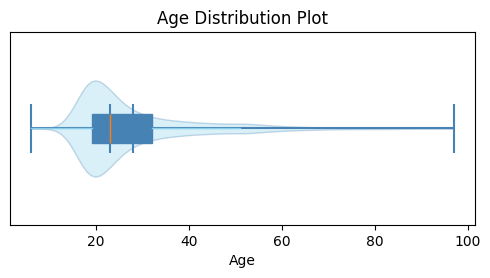

In [44]:
plt.figure(figsize=(6, 2.5))
plt.violinplot(df['age'], vert=False, showmeans=True, showextrema=True, showmedians=True)
for violin in plt.gca().collections:
    violin.set_facecolor("skyblue")
    violin.set_edgecolor("steelblue")
plt.boxplot(df['age'], vert=False, showmeans=False, showcaps=False, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", color='steelblue'), whiskerprops=dict(color='skyblue'),
            capprops=dict(color='skyblue'), flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
plt.title(f'Age Distribution Plot')
plt.xlabel(f'Age')
plt.yticks([])
plt.show()

We can remove the outliers of *age* by selecting the 99th percentile of the distribution.

In [45]:
# Selecting data up to 99th percentile
Q = df['age'].quantile(0.99)

df = df[df['age'] <= Q]
df.shape

(2903, 19)

## 2.2 Correlation between features

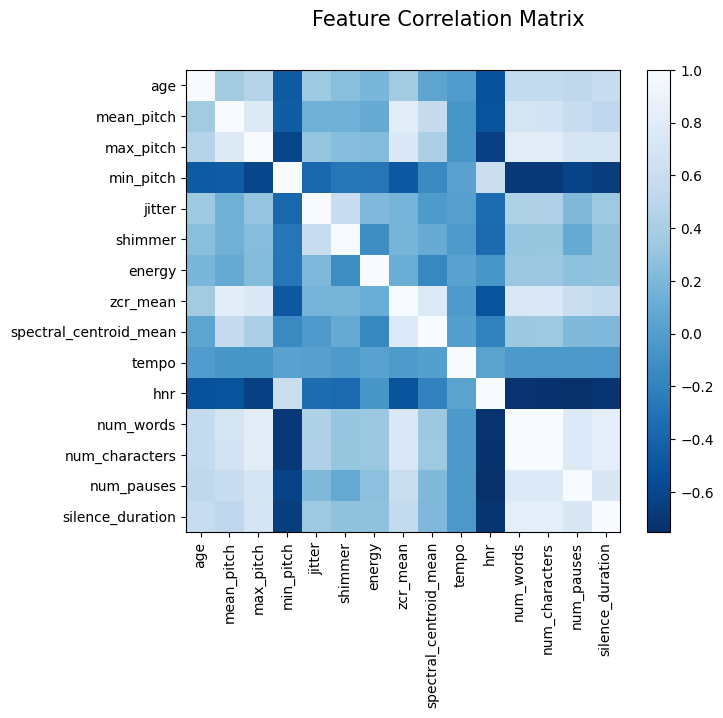

In [46]:
# Plot correlation Matrix
corr = df.drop(columns=['ethnicity','path','gender', 'Id']).corr(method='spearman')

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='Blues_r', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns)
plt.suptitle('Feature Correlation Matrix', fontsize=15)
plt.show()

We can observe that *num_words* and *num_characters* are higly correlated, as well as *duration* and *silence_duration*. We decide to remove *num_characters* and *silence_duration* from the dataset.

In [47]:
df = df.drop(columns=['num_characters', 'silence_duration'], axis=1)
eval_df = eval_df.drop(columns=['num_characters', 'silence_duration'], axis=1)

# 3 Data Preprocessing

## 3.1 Roll-off, Spectral Contrast and Duration extraction

In [48]:
def get_features(row):
    directory = 'DSL_Winter_Project_2025/'
    file_path = os.path.join(directory, row['path'])
    if os.path.isfile(file_path):
        y, sr = librosa.load(file_path, sr=SR)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        spectral_contrast_mean = np.mean(spectral_contrast, axis=1).mean()  
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)  
    
        return librosa.get_duration(y=y, sr=sr) , spectral_contrast_mean , spectral_rolloff_mean
    return np.nan, np.nan, np.nan, np.nan 

In [49]:
df[['duration', 'contrast', 'rolloff']] = df.apply(get_features, axis=1, result_type='expand')
eval_df[['duration', 'contrast', 'rolloff']] = eval_df.apply(get_features, axis=1, result_type='expand')

## 3.2 Standardization
We standardize the data using z-score normalization

In [50]:
num_feat = df.select_dtypes(include=['float64', 'int64']).columns
num_feat = num_feat.drop('age')
scaler = StandardScaler()
df[num_feat] = scaler.fit_transform(df[num_feat])
eval_df[num_feat] = scaler.transform(eval_df[num_feat])

## 3.3 Categorical features

In [51]:
dev_df['gender'].unique().size, dev_df['ethnicity'].unique().size

(2, 165)

Notice that _gender_ only assumes two distinct values (as expected), while the cardinality of _ethinicity_ is too high to directly apply One-Hot encoding. We can group together ethnicities with similar phonetic characteristics, according to 5 supergroups:
- Indo-European
- Afro-Asiatic
- Sino-Tibetan
- Austroasiatic & Pacific
- Other

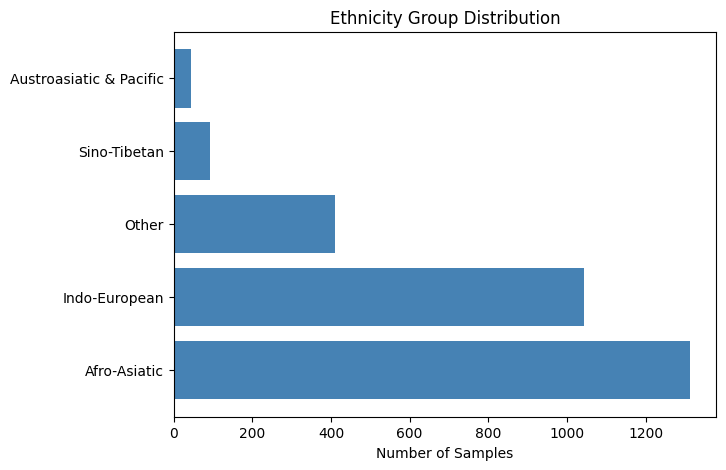

In [52]:
ethnicity_counts = dev_df['ethnicity'].value_counts()
ethnicity_percentage = (ethnicity_counts / ethnicity_counts.sum()) * 100

# Define grouped ethnicities
ethnicity_groups = {
    "Indo-European": [
        "english", "german", "dutch", "french", "italian", "spanish", "portuguese",
        "russian", "polish", "croatian", "icelandic", "armenian", "hindi", "bengali",
        "bosnian", "azerbaijani", "romanian", "albanian", "macedonian", "irish",
        "greek", "latvian", "lithuanian", "kazakh", "maltese", "finnish",
        "norwegian", "swedish", "danish", "estonian", "luxembourgeois", "faroese",
        "sardinian", "bavarian", "basque"
    ],
    "Afro-Asiatic": [
        "arabic", "hebrew", "amharic", "hausa", "coptic", "amazigh", "kabyle",
        "ethiopian", "akan", "yoruba", "igbo", "edo", "oromo", "kanuri", "fulani",
        "mandinka", "tiv", "bambara", "garifuna", "mende", "lingala", "rundi",
        "swahili", "kikuyu", "luo", "zulu", "xhosa", "bafang", "bamun", "ibibio",
        "mankanya", "ikwerre", "nigerian", "cameroonian", "ijaw", "annang", "fang",
        "ngemba"
    ],
    "Sino-Tibetan": [
        "mandarin", "cantonese", "gan", "hakka", "hainanese", "burmese", "tibetan",
        "chinese"
    ],
    "Austroasiatic & Pacific": [
        "filipino", "indonesian", "malay", "cebuano", "papiamentu", "hmong",
        "khmer", "lao", "vietnamese", "rotuman", "mauritian", "fijian", "pohnpeian", 
        "carolinian", "kiribati", "satawalese","lamotrekese", "mortlockese", "chamorro"
    ],
    "Other": [
        "unknown", "obudu", "ashanti", "kalanga", "nandi", "moba", "sarua",
        "kaire-kaire", "gedeo", "lamaholot", "dinka", "turkish", "kazakh", "kirghiz",
        "finnish", "hungarian", "estonian", "tamil", "telugu", "kannada", "malayalam"
    ]
}

# Function to map ethnicities to their corresponding group
def map_ethnicity(ethnicity):
    for group, ethnicities in ethnicity_groups.items():
        if ethnicity.lower() in ethnicities:
            return group
    return "Other"  # For rare cases not in mapping


df["ethnicity_group"] = df["ethnicity"].apply(map_ethnicity)
eval_df["ethnicity_group"] = eval_df["ethnicity"].apply(map_ethnicity)

plt.figure(figsize=(7, 5))
plt.barh(df['ethnicity_group'].value_counts().index, df['ethnicity_group'].value_counts(), color='steelblue')
plt.title('Ethnicity Group Distribution')
plt.xlabel('Number of Samples')
plt.show()
encoded_df = pd.get_dummies(df, columns=['gender', 'ethnicity_group'], dtype=int)
eval_df = pd.get_dummies(eval_df, columns=['gender', 'ethnicity_group'], dtype=int)

for col in encoded_df.columns:
    if col not in eval_df.columns:
        eval_df[col] = 0
eval_df = eval_df[encoded_df.columns].drop(columns=["age"])

## 3.4 Feature Selection

We use the Ridge regressor to perform regularization and feature selection.

In [53]:
df_dropped = encoded_df.drop(columns=['path', 'Id', 'ethnicity'])
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
reg = MLPRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2 Score: 0.3572
RMSE: 10.0111


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [55]:
reg = Ridge(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)

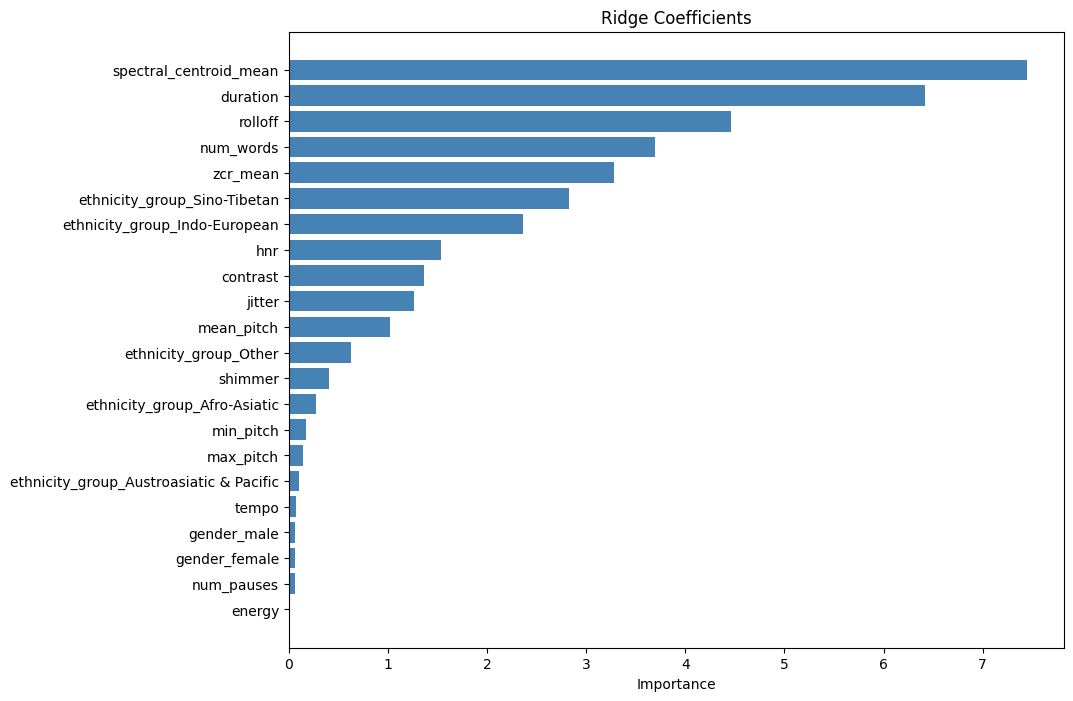

In [56]:
# Use the Ridge model to get feature importances
ndx = np.argsort(np.abs(reg.coef_))
features_df = pd.DataFrame(sorted(zip(feature_names[ndx], np.abs(reg.coef_)[ndx]), key=lambda x: x[1], reverse=False), columns=['Feature', 'Importance'])

plt.figure(figsize=(10, 8))
plt.barh(features_df['Feature'], features_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Ridge Coefficients')
plt.show()

Try to remove the features with low importance.

In [57]:
col_drop = ['num_pauses', 'energy', 'tempo']
print(f"Columns to drop: {col_drop}")
df_dropped = df_dropped.drop(columns=col_drop) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns

Columns to drop: ['num_pauses', 'energy', 'tempo']


In [58]:
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)
reg = MLPRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2 Score: 0.3540
RMSE: 10.1036


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [59]:
col_drop.append('Id')
df_dropped['path'] = dev_df['path']
dev_df = df_dropped.copy()

## 3.5 Feature Creation

From the original audio recordings we extract the first 13 MFCC and we perform PCA to reduce the final dimensionality.

In [60]:
def get_mfcc(row):
    directory = 'DSL_Winter_Project_2025/'
    file_path = os.path.join(directory, row['path'])
    if os.path.isfile(file_path):
        y, sr = librosa.load(file_path, sr=SR)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        return list(mfcc_mean)
    return [np.nan] * (13)

In [61]:
# Extract MFCC features
aux = pd.DataFrame()
aux[[f'mfcc_{i}' for i in range(13)]] = dev_df.apply(get_mfcc, axis=1, result_type='expand')
eval_aux = pd.DataFrame()
eval_aux[[f'mfcc_{i}' for i in range(13)]] = eval_df.apply(get_mfcc, axis=1, result_type='expand')

# Standardization
scaler = StandardScaler()
scaler.fit(aux)
aux = scaler.transform(aux)
eval_aux = scaler.transform(eval_aux)

pca = PCA(n_components=13)

aux_pca = pca.fit_transform(aux)
eval_aux_pca = pca.transform(eval_aux)

The cumulative expalined variance correponding to the 8th principal component is 0.8891


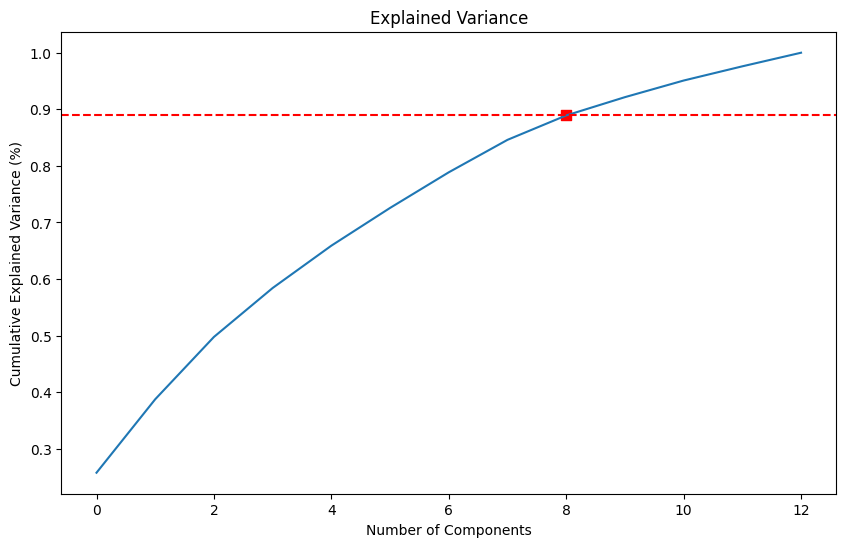

In [62]:
cum = np.cumsum(pca.explained_variance_ratio_)[8]
print(f"The cumulative expalined variance correponding to the 8th principal component is {cum:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)') 
plt.axhline(y=0.8891, color='r', linestyle='--')
plt.scatter(8,0.8891, color='red', s=50, marker='s')
plt.title('Explained Variance')
plt.show()

In [63]:
# We select the first 8 components, which correspond to 89% of the total explained variance
N = 8

pca = PCA(n_components=N)

aux_pca = pca.fit_transform(aux)
eval_aux_pca = pca.transform(eval_aux)

#### 3.5.1 WCCN
WCCN (Within-Class Covariance Normalization) is a technique used in machine learning to reduce session variability or intra-class variability in feature spaces. The idea is to normalize the feature space so that variability within the same class (e.g., same age group) is minimized. This helps the model focus on the between-class variability, which is essential for better classification or regression performance.
How WCCN Works
1. Within-Class Covariance Matrix:
Calculate the covariance matrix of feature vectors within each class (e.g., audio samples from the same age or speaker).
Combine the covariance matrices across all classes to form the overall within-class covariance matrix:
$$
S_W=\frac{1}{C}\sum_{c=1}^C\frac{1}{N_C}\sum_{i=1}^{N_C}(x_{c,i}−μ_c)(x_{c,i}−μ_c)^T
$$
Where:
- $x_{c,i}$: Feature vector for the i-th sample in class $c$.
- $μ_c$: Mean vector for class $c$
- $C$: Total number of classes.
- $N_c$: Number of samples in class $c$.
2. Transformation matrix:
We retrieve the final transformation matrix as the square root of the WCCN matrix:

$$
BB^T=B^2=S_W^{−1}
$$

$B$ is the WCCN transformation matrix.

3. Transform Feature Vectors:
- Apply the transformation $B$ to the feature vectors $x$:
$$
x_{normalized}=B^Tx
$$
- After this transformation, directions of high within-class variability are suppressed, making classes more separable.

In [64]:
def compute_within_class_cov(data, labels):
    unique_classes = np.unique(labels)
    num_features = data.shape[1]
    S_w = np.zeros((num_features, num_features))
    
    for clas in unique_classes:
        class_data = data[labels == clas]
        if class_data.shape[0] < 2:
            # Skip classes with fewer than 2 samples
            continue
        class_mean = np.mean(class_data, axis=0)
        cov_matrix = np.cov((class_data - class_mean).T)
        S_w += cov_matrix
    
    return S_w / len(unique_classes)

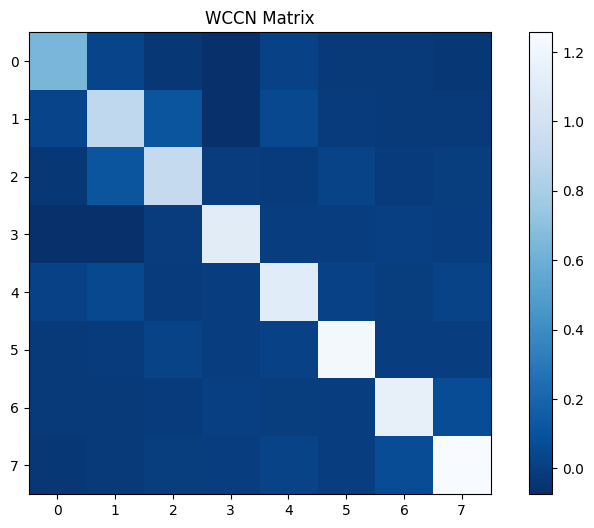

In [65]:
labels = dev_df['age'].values
S_w = compute_within_class_cov(aux_pca, labels)

# We apply a shift to the diagonal of the matrix to avoid singularities
alpha = 0.1
S_w_smoothed = (1 - alpha) * S_w + alpha * np.eye(S_w.shape[0])

wccn_matrix = scipy.linalg.sqrtm(np.linalg.inv(S_w_smoothed))

plt.figure(figsize=(10, 6))
plt.imshow(wccn_matrix, cmap='Blues_r', interpolation='none')
plt.title("WCCN Matrix")
plt.colorbar()
plt.show()

In [66]:
# Apply WCCN to data
aux_pca_wccn = aux_pca @ wccn_matrix.T
eval_aux_pca_wccn = eval_aux_pca @ wccn_matrix.T

num_features = aux_pca_wccn.shape[1]
columns = [f'feature_{i}' for i in range(num_features)]

dev_df[columns] = aux_pca_wccn
eval_df[columns] = eval_aux_pca_wccn

In [67]:
eval_df.set_index('Id', inplace=True)
col_drop.remove('Id')
dev_df = dev_df.drop(columns=['path'])
eval_df = eval_df.drop(columns=['path', 'ethnicity'])
eval_df = eval_df.drop(columns=col_drop)

# 4 Model Selection
We tested the following algorithms for the regression task:
- Decision Tree
- Random Forest
- Support Vector Machin
- Deep Learning

In [68]:
# Comparison among different models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=10, random_state=42),
    "Support Vector Machine": SVR(),
    "Deep Learning": MLPRegressor(random_state=42),
}

X = dev_df.drop(columns=["age"])
y = dev_df["age"]

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    r2_scores = []
    rmse_scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_valid)
        r2 = r2_score(y_valid, y_pred)
        rmse = root_mean_squared_error(y_valid, y_pred)
        r2_scores.append(r2)
        rmse_scores.append(rmse)
    print(f"{name}:")
    print(f"R^2 Score: {np.mean(r2_scores):.4f}")
    print(f"RMSE: {np.mean(rmse_scores):.4f}")
    print()

Decision Tree:
R^2 Score: -0.4032
RMSE: 14.1222

Random Forest:
R^2 Score: 0.2656
RMSE: 10.2292

Support Vector Machine:
R^2 Score: 0.2522
RMSE: 10.3354



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Deep Learning:
R^2 Score: 0.3484
RMSE: 9.6412



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# 5 Hyperparameter Tuning

We perform grid search on the hyperparameters of:
- Support Vector Machine Regressor
- Random Forest Regressor
- Deep Learning Regressor

In [69]:
# Grid Search on SVR
config = {
    "C": [10,15,17,20],
    "epsilon": [0.2, 1, 5],
    "kernel": ['poly', 'rbf']
}

min_rmse = float('inf')
best_params = {
    "C": None,
    "epsilon": None,
    "kernel": None
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for c in config["C"]:
    for eps in config["epsilon"]:
        for k in config["kernel"]:
            r2_scores = []
            rmse_scores = []
            for train_index, test_index in kf.split(X):
                X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
                y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
                model = SVR(C=c, epsilon=eps, kernel=k)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_valid)
                r2 = r2_score(y_valid, y_pred)
                rmse = root_mean_squared_error(y_valid, y_pred)
                r2_scores.append(r2)
                rmse_scores.append(rmse)
            if np.mean(rmse_scores) < min_rmse:
                min_rmse = np.mean(rmse_scores)
                best_params["C"] = c
                best_params["epsilon"] = eps
                best_params["kernel"] = k
            print(f"SVR (C={c}, epsilon={eps}, kernel={k}):")
            print(f"R^2 Score: {np.mean(r2_scores):.4f}")
            print(f"RMSE: {np.mean(rmse_scores):.4f}")
            print()
print(f"Best Model: (C = {best_params["C"]}, eps = {best_params["epsilon"]}, Kernel = {best_params['kernel']}) achieved RMSE: {min_rmse:.4f}")

SVR (C=10, epsilon=0.2, kernel=poly):
R^2 Score: 0.2566
RMSE: 10.3028

SVR (C=10, epsilon=0.2, kernel=rbf):
R^2 Score: 0.3187
RMSE: 9.8618

SVR (C=10, epsilon=1, kernel=poly):
R^2 Score: 0.2590
RMSE: 10.2861

SVR (C=10, epsilon=1, kernel=rbf):
R^2 Score: 0.3239
RMSE: 9.8238

SVR (C=10, epsilon=5, kernel=poly):
R^2 Score: 0.2850
RMSE: 10.1017

SVR (C=10, epsilon=5, kernel=rbf):
R^2 Score: 0.3435
RMSE: 9.6793

SVR (C=15, epsilon=0.2, kernel=poly):
R^2 Score: 0.2452
RMSE: 10.3807

SVR (C=15, epsilon=0.2, kernel=rbf):
R^2 Score: 0.3223
RMSE: 9.8343

SVR (C=15, epsilon=1, kernel=poly):
R^2 Score: 0.2496
RMSE: 10.3494

SVR (C=15, epsilon=1, kernel=rbf):
R^2 Score: 0.3285
RMSE: 9.7890

SVR (C=15, epsilon=5, kernel=poly):
R^2 Score: 0.2745
RMSE: 10.1728

SVR (C=15, epsilon=5, kernel=rbf):
R^2 Score: 0.3455
RMSE: 9.6637

SVR (C=17, epsilon=0.2, kernel=poly):
R^2 Score: 0.2391
RMSE: 10.4225

SVR (C=17, epsilon=0.2, kernel=rbf):
R^2 Score: 0.3222
RMSE: 9.8350

SVR (C=17, epsilon=1, kernel=poly):


In [70]:
# Grid Search on Random Forest Regressor

config = {
    "n_estimators": [200],
    "max_depth": [None, 10, 20],
    "max_features": ['sqrt', 'log2', None],
    "criterion": ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
}

min_rmse = float('inf')
best_params = {
    "n_estimators": None,
    "max_depth": None,
    "max_features": None,
    "criterion": None
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for n in config["n_estimators"]:
    for d in config["max_depth"]:
        for f in config["max_features"]:
            for c in config["criterion"]:
                r2_scores = []
                rmse_scores = []
                for train_index, test_index in kf.split(X):
                    X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
                    y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
                    model = RandomForestRegressor(n_estimators=n, max_depth=d, max_features=f, criterion=c, random_state=42)
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_valid)
                    r2 = r2_score(y_valid, y_pred)
                    rmse = root_mean_squared_error(y_valid, y_pred)
                    r2_scores.append(r2)
                    rmse_scores.append(rmse)
                if np.mean(rmse_scores) < min_rmse:
                    min_rmse = np.mean(rmse_scores)
                    best_params["n_estimators"] = n
                    best_params["max_depth"] = d
                    best_params["max_features"] = f
                    best_params["criterion"] = c
                print(f"Random Forest (n_estimators={n}, max_depth={d}, max_features={f}, criterion={c}):")
                print(f"R^2 Score: {np.mean(r2_scores):.4f}")
                print(f"RMSE: {np.mean(rmse_scores):.4f}")
                print()
print(f"Best Model: (n_estimators = {best_params['n_estimators']}, max_depth = {best_params['max_depth']}, max_features = {best_params['max_features']}, criterion = {best_params['criterion']}) achieved RMSE: {min_rmse:.4f}")

Random Forest (n_estimators=200, max_depth=None, max_features=sqrt, criterion=squared_error):
R^2 Score: 0.3378
RMSE: 9.7216

Random Forest (n_estimators=200, max_depth=None, max_features=sqrt, criterion=absolute_error):
R^2 Score: 0.3305
RMSE: 9.7748

Random Forest (n_estimators=200, max_depth=None, max_features=sqrt, criterion=friedman_mse):
R^2 Score: 0.3363
RMSE: 9.7332

Random Forest (n_estimators=200, max_depth=None, max_features=sqrt, criterion=poisson):
R^2 Score: 0.3354
RMSE: 9.7400

Random Forest (n_estimators=200, max_depth=None, max_features=log2, criterion=squared_error):
R^2 Score: 0.3415
RMSE: 9.6945

Random Forest (n_estimators=200, max_depth=None, max_features=log2, criterion=absolute_error):
R^2 Score: 0.3361
RMSE: 9.7342

Random Forest (n_estimators=200, max_depth=None, max_features=log2, criterion=friedman_mse):
R^2 Score: 0.3407
RMSE: 9.7005

Random Forest (n_estimators=200, max_depth=None, max_features=log2, criterion=poisson):
R^2 Score: 0.3398
RMSE: 9.7066

Rand

In [71]:
# Grid Search on MLPRegressor

config = {
    "hidden_layer_sizes": [(100,), (100, 100), (100, 100, 100)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ['constant', 'adaptive'],
}

min_rmse = float('inf')
best_params = {
    "hidden_layer_sizes": None,
    "alpha": None,
    "learning_rate": None,
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for h in config["hidden_layer_sizes"]:
    for a in config["alpha"]:
        for l in config["learning_rate"]:
            r2_scores = []
            rmse_scores = []
            for train_index, test_index in kf.split(X):
                X_train, X_valid = X.iloc[train_index], X.iloc[test_index]
                y_train, y_valid = y.iloc[train_index], y.iloc[test_index]
                model = MLPRegressor(hidden_layer_sizes=h, alpha=a, learning_rate=l, random_state=42)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_valid)
                r2 = r2_score(y_valid, y_pred)
                rmse = root_mean_squared_error(y_valid, y_pred)
                r2_scores.append(r2)
                rmse_scores.append(rmse)
            if np.mean(rmse_scores) < min_rmse:
                min_rmse = np.mean(rmse_scores)
                best_params["hidden_layer_sizes"] = h
                best_params["alpha"] = a
                best_params["learning_rate"] = l
            print(f"MLPRegressor (hidden_layer_sizes={h}, alpha={a}, learning_rate={l}):")
            print(f"R^2 Score: {np.mean(r2_scores):.4f}")
            print(f"RMSE: {np.mean(rmse_scores):.4f}")
            print()
print(f"Best Model: (hidden_layer_sizes = {best_params['hidden_layer_sizes']}, alpha = {best_params['alpha']}, learning_rate = {best_params['learning_rate']}) achieved RMSE: {min_rmse:.4f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor (hidden_layer_sizes=(100,), alpha=0.0001, learning_rate=constant):
R^2 Score: 0.3484
RMSE: 9.6412



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor (hidden_layer_sizes=(100,), alpha=0.0001, learning_rate=adaptive):
R^2 Score: 0.3484
RMSE: 9.6412



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor (hidden_layer_sizes=(100, 100, 100), alpha=0.01, learning_rate=constant):
R^2 Score: -0.0439
RMSE: 12.1901



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor (hidden_layer_sizes=(100, 100, 100), alpha=0.01, learning_rate=adaptive):
R^2 Score: -0.0439
RMSE: 12.1901

Best Model: (hidden_layer_sizes = (100,), alpha = 0.01, learning_rate = constant) achieved RMSE: 9.6410


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# 6 Evaluation

In [72]:
# We make the predictions using the tuned SVR model

reg = SVR(C=17, epsilon=5, kernel='rbf')
X = dev_df.drop(columns=["age"])
y = dev_df["age"]
reg.fit(X, y)
y_pred = reg.predict(eval_df)

with open('TESTS/predictions_final_SVR.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")

In [73]:
# We make the predictions using the tuned Random Forest Regressor model

reg = RandomForestRegressor(n_estimators=200, max_depth=10, max_features='sqrt', criterion='poisson', random_state=42)
X = dev_df.drop(columns=["age"])
y = dev_df["age"]
reg.fit(X, y)
y_pred = reg.predict(eval_df)

with open('TESTS/predictions_final_RF.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")

In [74]:
# We make the predictions using the tuned MPLRegressor model

reg = MLPRegressor(hidden_layer_sizes = (100,), alpha = 0.01, learning_rate = 'constant', random_state=42)
X = dev_df.drop(columns=["age"])
y = dev_df["age"]
reg.fit(X, y)
y_pred = reg.predict(eval_df)

with open('TESTS/predictions_final_MLP.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# 7. Baseline

In [75]:
dev_df = pd.read_csv("DSL_Winter_Project_2025/development.csv")
eval_df = pd.read_csv("DSL_Winter_Project_2025/evaluation.csv")

In [76]:
# define a copy of the df to work on
df = dev_df.copy() 

In [77]:
df['tempo'] = df['tempo'].str.replace('[', '').str.replace(']', '').astype('float64')
eval_df['tempo'] = eval_df['tempo'].str.replace('[', '').str.replace(']', '').astype('float64')

## 7.1 Naive solution

In [78]:
mean_age = df['age'].mean()
y_pred = np.full((eval_df.shape[0],), mean_age)
with open('TESTS/naive.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")

## 7.2 Simple model

In [79]:
df.drop(columns=['ethnicity', 'path', 'gender'], inplace=True)
eval_df.drop(columns=['ethnicity', 'path', 'gender'], inplace=True)  

In [80]:
reg = LinearRegression()
X = df.drop(columns=["age"])
y = df["age"]
reg.fit(X, y)
y_pred = reg.predict(eval_df)

with open('TESTS/simple_solution.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")